### Caricamento di un Dataset.

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("zadafiyabhrami/global-crocodile-species-dataset")

# print("Path to dataset files:", path)

In [5]:
import pandas as pd

In [23]:
df = pd.read_csv(r"data\raw\crocodile_dataset.csv")
df.head()

,Observation ID,Common Name,Scientific Name,Family,Genus,Observed Length (m),Observed Weight (kg),Age Class,Sex,Date of Observation,Country/Region,Habitat Type,Conservation Status,Observer Name,Notes
0,1,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,1.90,62.0,Adult,Male,31-03-2018,Belize,Swamps,Least Concern,Allison Hill,Cause bill scientist nation opportunity.
1,2,American Crocodile,Crocodylus acutus,Crocodylidae,Crocodylus,4.09,334.5,Adult,Male,28-01-2015,Venezuela,Mangroves,Vulnerable,Brandon Hall,Ago current practice nation determine operatio...
2,3,Orinoco Crocodile,Crocodylus intermedius,Crocodylidae,Crocodylus,1.08,118.2,Juvenile,Unknown,07-12-2010,Venezuela,Flooded Savannas,Critically Endangered,Melissa Peterson,Democratic shake bill here grow gas enough ana...
3,4,Morelet's Crocodile,Crocodylus moreletii,Crocodylidae,Crocodylus,2.42,90.4,Adult,Male,01-11-2019,Mexico,Rivers,Least Concern,Edward Fuller,Officer relate animal direction eye bag do.
4,5,Mugger Crocodile (Marsh Crocodile),Crocodylus palustris,Crocodylidae,Crocodylus,3.75,269.4,Adult,Unknown,15-07-2019,India,Rivers,Vulnerable,Donald Reid,Class great prove reduce raise author play mov...


In [28]:
import re
import pandas as pd
from typing import Dict, List, Optional

COMMON_DATE_FORMATS = [
    "%Y-%m-%d", "%d-%m-%Y", "%m-%d-%Y",
    "%d/%m/%Y", "%m/%d/%Y", "%d.%m.%Y", "%Y/%m/%d",
    "%d %b %Y", "%d %B %Y",
]
_DATEY_LOOK = re.compile(r"^[\d]{1,4}([\-\/\.\s])[\dA-Za-z]{1,3}\1[\d]{2,4}$")

def _infer_dayfirst(series: pd.Series) -> bool:
    """Euristica: se la prima componente > 12 in molti valori, assumo dayfirst=True."""
    s = series.dropna().astype(str)
    if s.empty: 
        return True  # default EU
    sample = s.sample(min(len(s), 400), random_state=0)
    tokens = sample.str.replace(r"[^\d\/\-\.\s]", "", regex=True).str.split(r"[\/\-\.\s]+", regex=True)
    first_nums = tokens.apply(lambda t: int(t[0]) if t and t[0].isdigit() else None)
    # Conta quante volte il primo numero è >12 (quindi plausibile giorno)
    ratio_day_gt_12 = (first_nums.dropna() > 12).mean() if first_nums.notna().any() else 0.0
    return bool(ratio_day_gt_12 >= 0.2)  # soglia morbida

def try_parse_datetime(series: pd.Series, min_parse_rate: float = 0.8,
                       dayfirst_default: Optional[bool] = None) -> Optional[pd.Series]:
    s = series.dropna()
    if len(s) == 0:
        return None
    # quick pre-check: sembra una data?
    sample = s.astype(str)
    sample = sample.sample(min(len(sample), 200), random_state=0)
    looks_like_date = (
        sample.str.len().between(6, 32) &
        (sample.str.match(_DATEY_LOOK) | sample.str.contains(r"[A-Za-z]{3}", regex=True))
    )
    if looks_like_date.mean() < 0.3:
        return None

    # inferisci dayfirst se non specificato
    dayfirst = _infer_dayfirst(series) if dayfirst_default is None else bool(dayfirst_default)

    # 1) parser moderno (pandas ≥2): format="mixed" per formati misti
    parsed = pd.to_datetime(series, errors="coerce", dayfirst=dayfirst, format="mixed")
    rate = parsed.notna().mean()

    # 2) fallback su formati espliciti
    if rate < min_parse_rate:
        best, best_rate = parsed, rate
        for fmt in COMMON_DATE_FORMATS:
            p = pd.to_datetime(series, errors="coerce", format=fmt)
            r = p.notna().mean()
            if r > best_rate:
                best, best_rate = p, r
            if best_rate >= min_parse_rate:
                break
        parsed, rate = best, best_rate

    return parsed if rate >= min_parse_rate else None

def detect_datetime_columns(df: pd.DataFrame, min_parse_rate: float = 0.8) -> Dict[str, float]:
    results = {}
    for col in df.columns:
        ser = df[col]
        if pd.api.types.is_datetime64_any_dtype(ser):
            results[col] = 1.0
        elif pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            parsed = try_parse_datetime(ser, min_parse_rate=min_parse_rate, dayfirst_default=None)
            if parsed is not None:
                results[col] = float(parsed.notna().mean())
    return results

def coerce_datetime_inplace(df: pd.DataFrame, min_parse_rate: float = 0.8,
                            dayfirst_default: Optional[bool] = None) -> List[str]:
    converted = []
    for col in df.columns:
        ser = df[col]
        if pd.api.types.is_datetime64_any_dtype(ser):
            continue
        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_string_dtype(ser):
            parsed = try_parse_datetime(ser, min_parse_rate=min_parse_rate,
                                        dayfirst_default=dayfirst_default)
            if parsed is not None:
                df[col] = parsed
                converted.append(col)
    return converted


In [29]:
import pandas as pd
import re

_WORD_RE = re.compile(r"\w+", flags=re.UNICODE)

def _text_stats(ser: pd.Series) -> dict:
    s = ser.dropna().astype(str)
    if s.empty:
        return dict(avg_chars=0, avg_words=0, unique_token_ratio=0.0, pct_long_lines=0.0)
    lens = s.str.len()
    words = s.str.findall(_WORD_RE).apply(len)
    sample = s.sample(min(len(s), 500), random_state=0)
    tokens = _WORD_RE.findall(" ".join(sample.tolist()).lower())
    vocab = set(tokens)
    utr = len(vocab) / max(len(tokens), 1)
    return dict(
        avg_chars=float(lens.mean()),
        avg_words=float(words.mean()),
        unique_token_ratio=float(utr),
        pct_long_lines=float((lens >= 120).mean()),
    )

def _looks_like_long_text(stats: dict, min_avg_chars=120, min_avg_words=20, min_utr=0.2):
    return (stats["avg_chars"] >= min_avg_chars or stats["avg_words"] >= min_avg_words) and (stats["unique_token_ratio"] >= min_utr)

def _categorical_values_preview(ser: pd.Series, max_cat_values: int = 10):
    nuniq = ser.nunique(dropna=True)
    if nuniq == 0:
        return [], 0, False
    if nuniq > max_cat_values:
        return None, nuniq, True
    vals = sorted(ser.dropna().astype(str).unique().tolist(), key=lambda x: x.lower())
    return vals, int(nuniq), False

def categorize_columns(
    df: pd.DataFrame,
    threshold_cat: int = 20,
    max_cat_values: int = 10,
    nlp_avg_chars: int = 120,
    nlp_avg_words: int = 20,
    nlp_min_unique_token_ratio: float = 0.2,
    auto_parse_dates: bool = True,
) -> dict:
    if auto_parse_dates:
        coerce_datetime_inplace(df, min_parse_rate=0.8, dayfirst_default=None)

    cats = {
        "numeriche_continue": [],
        "numeriche_discrete": [],
        "categoriche": {},      # {col: {n_unique, values/None, truncated}}
        "boolean": [],
        "datetime": [],
        "testo_libero": [],
        "long_text_nlp": {},    # {col: stats}
    }

    for col in df.columns:
        ser = df[col]

        # boolean
        if pd.api.types.is_bool_dtype(ser) or (pd.api.types.is_integer_dtype(ser) and ser.dropna().isin([0, 1]).all()):
            cats["boolean"].append(col); continue

        # datetime
        if pd.api.types.is_datetime64_any_dtype(ser):
            cats["datetime"].append(col); continue

        # numeric
        if pd.api.types.is_numeric_dtype(ser):
            (cats["numeriche_discrete"] if ser.nunique(dropna=True) <= threshold_cat else cats["numeriche_continue"]).append(col)
            continue

        # text-like
        if pd.api.types.is_object_dtype(ser) or pd.api.types.is_categorical_dtype(ser):
            stats = _text_stats(ser)
            if _looks_like_long_text(stats, nlp_avg_chars, nlp_avg_words, nlp_min_unique_token_ratio):
                cats["long_text_nlp"][col] = stats
            else:
                nuniq = ser.nunique(dropna=True)
                if nuniq <= threshold_cat:
                    values, n_unique, truncated = _categorical_values_preview(ser, max_cat_values=max_cat_values)
                    cats["categoriche"][col] = {"n_unique": n_unique, "values": values, "truncated": truncated}
                else:
                    cats["testo_libero"].append(col)
            continue

        # fallback
        values, n_unique, truncated = _categorical_values_preview(ser, max_cat_values=max_cat_values)
        cats["categoriche"][col] = {"n_unique": n_unique, "values": values, "truncated": truncated}

    return cats


In [35]:
df["Observer Name"].unique()

array(['Allison Hill', 'Brandon Hall', 'Melissa Peterson',
       'Edward Fuller', 'Donald Reid', 'Randy Brown',
       'Dr. Marvin Thomas Jr.', 'Terri Frazier', 'Deborah Mason',
       'Tamara George', 'Betty Alvarez', 'Jennifer Powers', 'Mark Perez',
       'Timothy Duncan', 'Matthew Lucas', 'Donald Wright', 'Sarah Martin',
       'Amy Edwards', 'Kurt Leonard', 'Matthew Cunningham', 'Paul Jones',
       'Dustin Kim', 'Mark Baker', 'Jacob Tran', 'David Garcia',
       'Shane Garrison', 'Donald Jones', 'Mrs. Linda Reed',
       'Christina Reynolds', 'Jamie Adkins', 'Julie Ramos', 'Eric Drake',
       'Matthew Smith', 'Casey Marshall', 'Denise Jones', 'Ross Price',
       'Morgan Marsh', 'Mary Miller', 'Paul Decker', 'Lisa Allen',
       'Miguel Jones', 'Christopher Boyd', 'Laura Barnett',
       'Peter Vaughn DDS', 'Eric Hall', 'Paige Carlson', 'Edgar Raymond',
       'Tiffany Miller', 'Elizabeth Oliver DDS', 'Jerry Wheeler',
       'Dennis Moody', 'Melissa Bender', 'Joseph Ramos', 'Ga

In [40]:
schema = categorize_columns(df, threshold_cat=50)

In [ ]:
{'numeriche_continue': ['Observation ID',
  'Observed Length (m)',
  'Observed Weight (kg)'],
 'numeriche_discrete': [],
 'categoriche': {'Common Name': {'n_unique': 18,
   'values': None,
   'truncated': True},
  'Scientific Name': {'n_unique': 18, 'values': None, 'truncated': True},
  'Family': {'n_unique': 1, 'values': ['Crocodylidae'], 'truncated': False},
  'Genus': {'n_unique': 3,
   'values': ['Crocodylus', 'Mecistops', 'Osteolaemus'],
   'truncated': False},
  'Age Class': {'n_unique': 4,
   'values': ['Adult', 'Hatchling', 'Juvenile', 'Subadult'],
   'truncated': False},
  'Sex': {'n_unique': 3,
   'values': ['Female', 'Male', 'Unknown'],
   'truncated': False},
  'Country/Region': {'n_unique': 47, 'values': None, 'truncated': True},
  'Habitat Type': {'n_unique': 29, 'values': None, 'truncated': True},
  'Conservation Status': {'n_unique': 5,
   'values': ['Critically Endangered',
    'Data Deficient',
    'Endangered',
    'Least Concern',
    'Vulnerable'],
   'truncated': False}},
 'boolean': [],
 'datetime': ['Date of Observation'],
 'testo_libero': ['Observer Name', 'Notes'],
 'long_text_nlp': {}}

## Analisi univariata

In [41]:
from typing import Dict, Any, List, Optional, Tuple
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

def _infer_type_from_schema(col: str, schema: Dict[str, Any]) -> str:
    """Ritorna il tipo alto livello della colonna in base allo schema."""
    if col in schema.get("numeriche_continue", []):
        return "numerica_continua"
    if col in schema.get("numeriche_discrete", []):
        return "numerica_discreta"
    if col in schema.get("datetime", []):
        return "datetime"
    if col in schema.get("boolean", []):
        return "boolean"
    if col in schema.get("testo_libero", []):
        return "testo_libero"
    # categoriche è un dict: {col: {n_unique, values, truncated}}
    if col in schema.get("categoriche", {}):
        return "categorica"
    if col in schema.get("long_text_nlp", {}):
        return "long_text_nlp"
    # fallback: prova a inferire
    return "sconosciuto"

def _basic_missingness(s: pd.Series) -> Dict[str, Any]:
    n = len(s)
    miss = int(s.isna().sum())
    return {
        "n": n,
        "missing": miss,
        "missing_pct": float(miss) / n * 100 if n > 0 else np.nan,
        "n_unique": int(s.nunique(dropna=True))
    }

def _numeric_stats(s: pd.Series) -> Dict[str, Any]:
    s_num = pd.to_numeric(s, errors="coerce")
    desc = s_num.describe(percentiles=[.05,.25,.5,.75,.95])
    out = _basic_missingness(s)
    out.update({
        "count_non_null": int(desc.get("count", 0)),
        "mean": float(desc.get("mean", np.nan)),
        "std": float(desc.get("std", np.nan)),
        "min": float(desc.get("min", np.nan)),
        "p05": float(desc.get("5%", np.nan)),
        "q1": float(desc.get("25%", np.nan)),
        "median": float(desc.get("50%", np.nan)),
        "q3": float(desc.get("75%", np.nan)),
        "p95": float(desc.get("95%", np.nan)),
        "max": float(desc.get("max", np.nan)),
        "skew": float(s_num.skew(skipna=True)) if desc.get("count", 0) > 2 else np.nan,
        "kurtosis": float(s_num.kurtosis(skipna=True)) if desc.get("count", 0) > 2 else np.nan,
        "zeros": int((s_num == 0).sum(skipna=True)) if desc.get("count", 0) > 0 else 0,
        "negatives": int((s_num < 0).sum(skipna=True)) if desc.get("count", 0) > 0 else 0,
    })
    return out

def _plot_histogram(s: pd.Series, bins: Optional[int] = None) -> plt.Figure:
    s_num = pd.to_numeric(s, errors="coerce").dropna()
    if bins is None:
        # Freedman–Diaconis bin width
        q1, q3 = np.percentile(s_num, [25, 75]) if len(s_num) > 0 else (np.nan, np.nan)
        iqr = q3 - q1 if (not math.isnan(q3) and not math.isnan(q1)) else None
        if iqr and iqr > 0:
            binw = 2 * iqr / (len(s_num) ** (1/3))
            bins = max(10, int(np.ceil((s_num.max() - s_num.min()) / binw))) if binw > 0 else 30
        else:
            bins = 30
    fig = plt.figure()
    plt.hist(s_num, bins=bins)
    plt.title("Distribuzione (istogramma)")
    plt.xlabel("Valore")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    return fig

def _plot_boxplot(s: pd.Series) -> plt.Figure:
    s_num = pd.to_numeric(s, errors="coerce").dropna()
    fig = plt.figure()
    plt.boxplot(s_num, vert=True, whis=1.5, showfliers=True)
    plt.title("Boxplot")
    plt.ylabel("Valore")
    plt.tight_layout()
    return fig

def _categorical_stats(s: pd.Series, top_k: int = 20) -> Tuple[Dict[str, Any], pd.DataFrame]:
    out = _basic_missingness(s)
    vc = s.astype("object").fillna(pd.NA).value_counts(dropna=False)
    # entropia di Shannon (su valori non-null)
    p = (s.dropna().value_counts(normalize=True))
    entropy = float(-(p * np.log2(p)).sum()) if len(p) > 0 else np.nan
    out.update({
        "top_k": top_k,
        "entropy_bits": entropy,
        "max_freq": int(vc.iloc[0]) if len(vc) else 0,
        "max_cat": None if len(vc)==0 else str(vc.index[0]),
    })
    top_table = vc.head(top_k).rename_axis("category").reset_index(name="count")
    top_table["pct"] = top_table["count"] / len(s) * 100 if len(s) else 0.0
    return out, top_table

def _plot_bar_counts(table: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(8, max(3, 0.3 * len(table))))
    plt.barh(table["category"].astype(str), table["count"])
    plt.title("Frequenze (prime categorie)")
    plt.xlabel("Conteggio")
    plt.ylabel("Categoria")
    plt.tight_layout()
    return fig

def _plot_pie_counts(table: pd.DataFrame, max_slices: int = 8) -> plt.Figure:
    t = table.head(max_slices)
    fig = plt.figure()
    plt.pie(t["count"], labels=t["category"].astype(str), autopct="%1.1f%%", startangle=90)
    plt.title("Distribuzione (prime categorie)")
    plt.tight_layout()
    return fig

def _datetime_stats(s: pd.Series) -> Dict[str, Any]:
    out = _basic_missingness(s)
    s_dt = pd.to_datetime(s, errors="coerce")
    out.update({
        "min": s_dt.min(),
        "max": s_dt.max(),
        "range_days": (s_dt.max() - s_dt.min()).days if s_dt.notna().any() else np.nan
    })
    return out

def _plot_timeseries_counts(s: pd.Series, freq: str = "M") -> plt.Figure:
    s_dt = pd.to_datetime(s, errors="coerce").dropna()
    counts = s_dt.dt.to_period(freq).value_counts().sort_index()
    idx = counts.index.astype(str)
    fig = plt.figure()
    plt.plot(range(len(counts)), counts.values, marker="o")
    plt.title(f"Conteggi per periodo ({freq})")
    plt.xlabel("Periodo")
    plt.ylabel("Conteggio")
    # Etichette poco fitte per leggibilità
    step = max(1, len(idx)//12)
    plt.xticks(range(0, len(idx), step), idx[::step], rotation=45, ha="right")
    plt.tight_layout()
    return fig

def _boolean_stats(s: pd.Series) -> Dict[str, Any]:
    out = _basic_missingness(s)
    s_bool = s.astype("boolean")
    true_c = int((s_bool == True).sum())
    false_c = int((s_bool == False).sum())
    out.update({
        "true": true_c,
        "false": false_c,
        "true_pct": true_c / (true_c + false_c) * 100 if (true_c + false_c) else np.nan
    })
    return out

def _text_free_stats(s: pd.Series, top_k: int = 20) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """Analisi leggera per testo 'breve' (testo_libero): cardinalità + lunghezze + top valori."""
    out = _basic_missingness(s)
    s_str = s.astype("string")
    lengths = s_str.dropna().str.len()
    out.update({
        "avg_length": float(lengths.mean()) if len(lengths) else np.nan,
        "p95_length": float(lengths.quantile(0.95)) if len(lengths) else np.nan,
        "max_length": int(lengths.max()) if len(lengths) else np.nan,
    })
    top = s_str.value_counts(dropna=True).head(top_k).rename_axis("value").reset_index(name="count")
    top["pct"] = top["count"] / len(s) * 100 if len(s) else 0.0
    return out, top

def analyze_column(
    column: str,
    df: pd.DataFrame,
    schema: Dict[str, Any],
    plots: bool = True,
    top_k_categories: int = 20
) -> Dict[str, Any]:
    """
    Analizza una colonna 'column' di df in base allo schema fornito.
    Ritorna:
      - col_type: tipo individuato
      - stats: dizionario di statistiche
      - figures: lista di matplotlib.figure.Figure (grafici creati)
    """
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non trovata nel dataframe.")
    s = df[column]
    col_type = _infer_type_from_schema(column, schema)
    figures: List[plt.Figure] = []
    stats: Dict[str, Any] = {"column": column, "type": col_type}

    # Routing per tipo
    if col_type in ("numerica_continua", "numerica_discreta"):
        stats.update(_numeric_stats(s))
        if plots:
            if col_type == "numerica_discreta":
                # Per discrete: barplot dei conteggi (prime categorie)
                vc = pd.to_numeric(s, errors="coerce").dropna().astype(int).value_counts().sort_index()
                table = vc.rename_axis("value").reset_index(name="count").head(top_k_categories)
                fig_bar = plt.figure(figsize=(8, max(3, 0.3 * len(table))))
                plt.bar(table["value"].astype(str), table["count"])
                plt.title("Frequenze (valori discreti)")
                plt.xlabel("Valore")
                plt.ylabel("Conteggio")
                plt.tight_layout()
                figures.append(fig_bar)
            else:
                figures.append(_plot_histogram(s))
                figures.append(_plot_boxplot(s))

    elif col_type == "categorica":
        cat_stats, top_table = _categorical_stats(s, top_k=top_k_categories)
        stats.update(cat_stats)
        stats["top_table"] = top_table.to_dict(orient="records")
        if plots and len(top_table) > 0:
            figures.append(_plot_bar_counts(top_table))
            figures.append(_plot_pie_counts(top_table))

    elif col_type == "datetime":
        stats.update(_datetime_stats(s))
        if plots:
            try:
                figures.append(_plot_timeseries_counts(s, freq="M"))
            except Exception:
                pass

    elif col_type == "boolean":
        stats.update(_boolean_stats(s))
        if plots:
            # semplice bar su true/false
            fig = plt.figure()
            vals = [stats.get("false", 0), stats.get("true", 0)]
            plt.bar(["False", "True"], vals)
            plt.title("Distribuzione boolean")
            plt.xlabel("Valore")
            plt.ylabel("Conteggio")
            plt.tight_layout()
            figures.append(fig)

    elif col_type == "testo_libero":
        txt_stats, top_vals = _text_free_stats(s, top_k=top_k_categories)
        stats.update(txt_stats)
        stats["top_values"] = top_vals.to_dict(orient="records")
        if plots and len(top_vals) > 0:
            # bar delle prime occorrenze
            fig = plt.figure(figsize=(8, max(3, 0.3 * len(top_vals))))
            plt.barh(top_vals["value"].astype(str), top_vals["count"])
            plt.title("Top valori (testo libero)")
            plt.xlabel("Conteggio")
            plt.ylabel("Valore")
            plt.tight_layout()
            figures.append(fig)

    elif col_type == "long_text_nlp":
        stats["note"] = "Pass: l’analisi NLP verrà integrata successivamente."
        # niente grafici

    else:
        # fallback euristico: prova numerico, poi categorico
        try:
            pd.to_numeric(s, errors="raise")
            stats["note"] = "Tipo non in schema: trattato come numerico (euristico)."
            stats.update(_numeric_stats(s))
            if plots:
                figures.append(_plot_histogram(s))
                figures.append(_plot_boxplot(s))
            col_type = "numerico_heuristic"
        except Exception:
            stats["note"] = "Tipo non in schema: trattato come categorico (euristico)."
            cat_stats, top_table = _categorical_stats(s, top_k=top_k_categories)
            stats.update(cat_stats)
            stats["top_table"] = top_table.to_dict(orient="records")
            if plots and len(top_table) > 0:
                figures.append(_plot_bar_counts(top_table))
                figures.append(_plot_pie_counts(top_table))
            col_type = "categorico_heuristic"

    return {"col_type": col_type, "stats": stats, "figures": figures}


{'column': 'Observed Length (m)', 'type': 'numerica_continua', 'n': 1000, 'missing': 0, 'missing_pct': 0.0, 'n_unique': 390, 'count_non_null': 1000, 'mean': 2.41511, 'std': 1.0975422483380248, 'min': 0.14, 'p05': 0.6, 'q1': 1.6375, 'median': 2.43, 'q3': 3.01, 'p95': 4.35, 'max': 6.12, 'skew': 0.34738581724459877, 'kurtosis': 0.2298433758328282, 'zeros': 0, 'negatives': 0}
29 categorie
{'column': 'Date of Observation', 'type': 'datetime', 'n': 1000, 'missing': 0, 'missing_pct': 0.0, 'n_unique': 936, 'min': Timestamp('2005-01-29 00:00:00'), 'max': Timestamp('2025-12-23 00:00:00'), 'range_days': 7633}
{'column': 'Notes', 'type': 'testo_libero', 'n': 1000, 'missing': 0, 'missing_pct': 0.0, 'n_unique': 1000, 'avg_length': 63.292, 'p95_length': 108.0, 'max_length': 152, 'top_values': [{'value': 'Cause bill scientist nation opportunity.', 'count': 1, 'pct': 0.1}, {'value': 'Ago current practice nation determine operation speak according.', 'count': 1, 'pct': 0.1}, {'value': 'Democratic shake 

C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\1068183902.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\1068183902.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\1068183902.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\3392383966.py:251: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


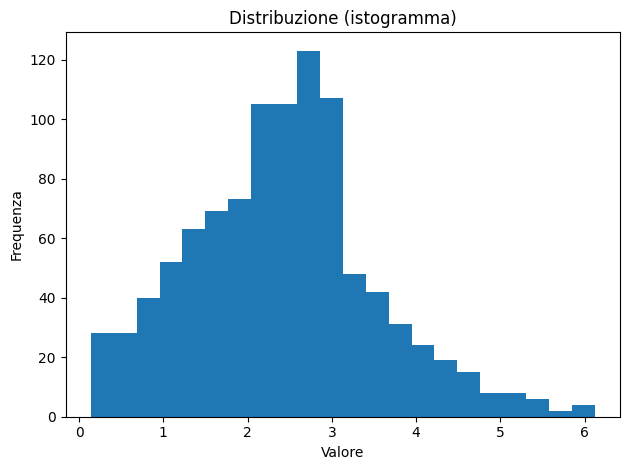

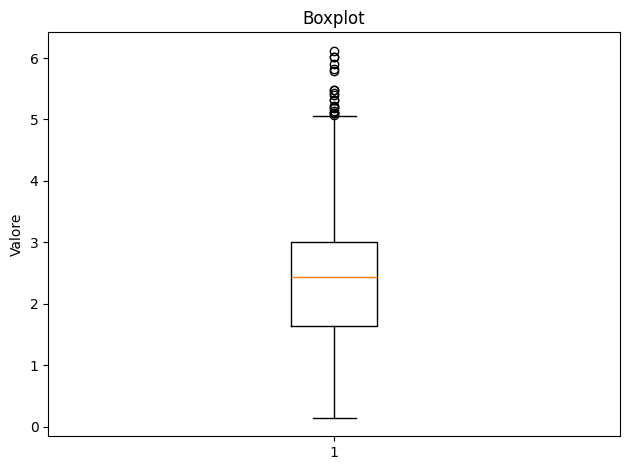

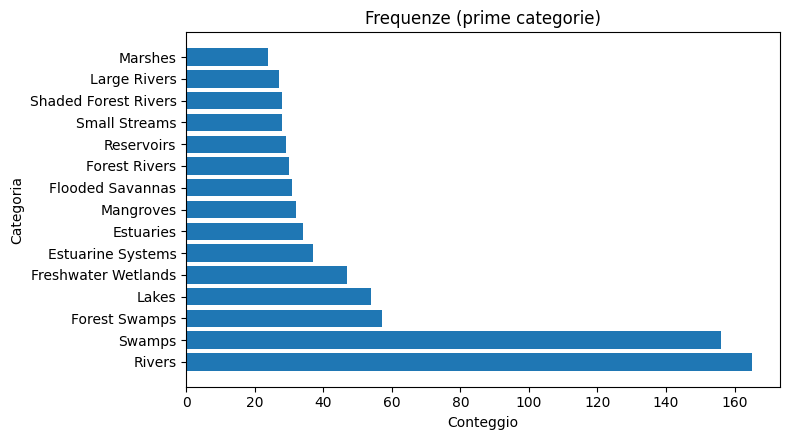

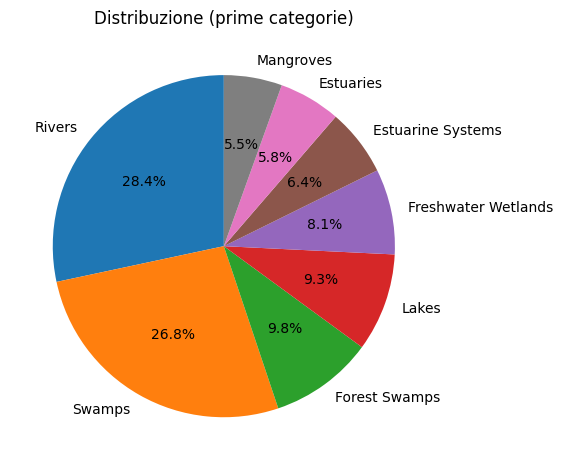

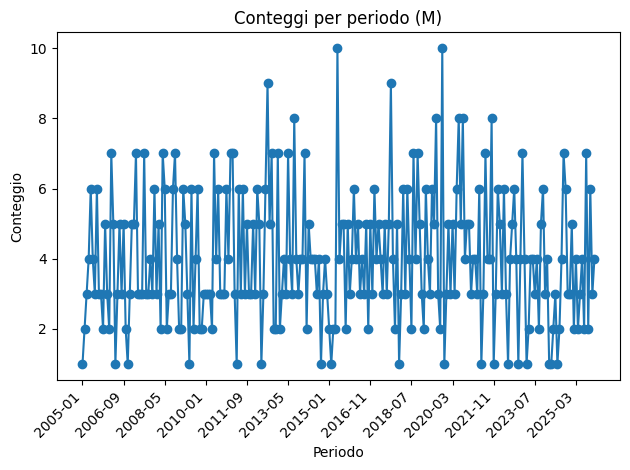

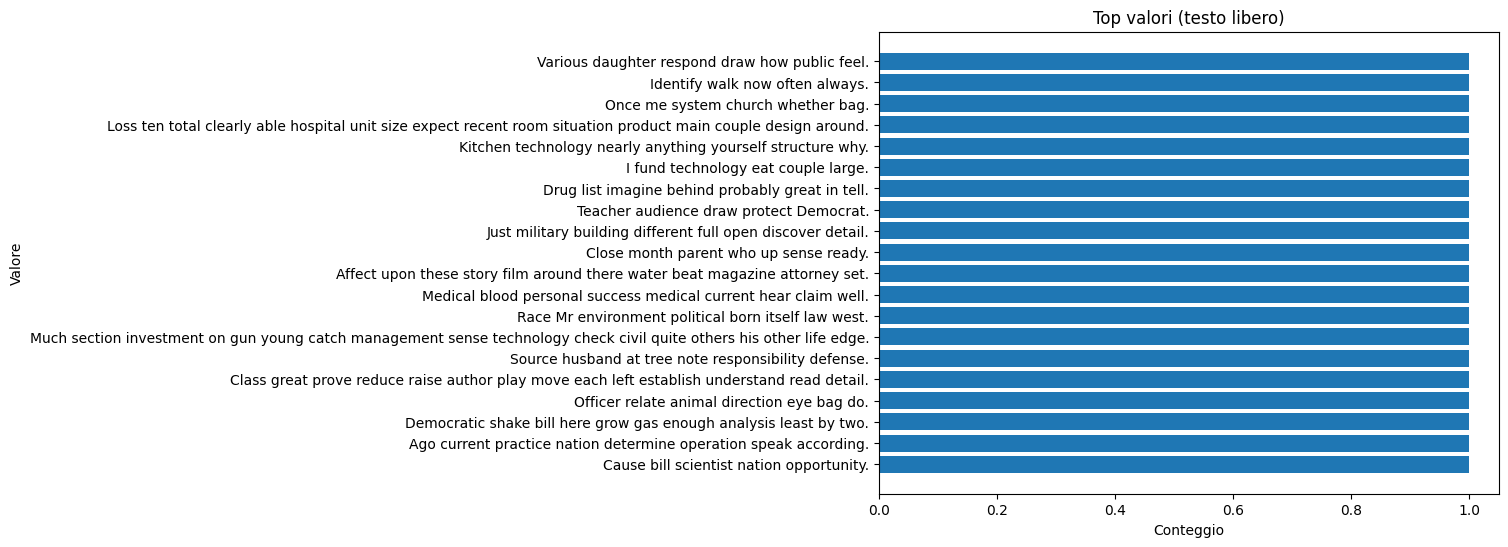

In [42]:
# 1) Analisi di una numerica continua
res_len = analyze_column("Observed Length (m)", df, schema)
print(res_len["stats"])         # dizionario di metriche
for fig in res_len["figures"]:  # mostra i grafici (in notebook/IDE)
    fig.show()

# 2) Analisi di una categorica
res_hab = analyze_column("Habitat Type", df, schema, top_k_categories=15)
print(res_hab["stats"]["n_unique"], "categorie")
for fig in res_hab["figures"]:
    fig.show()

# 3) Analisi datetime
res_date = analyze_column("Date of Observation", df, schema)
print(res_date["stats"])
for fig in res_date["figures"]:
    fig.show()

# 4) Testo libero
res_notes = analyze_column("Notes", df, schema)
print(res_notes["stats"])


## ANALISI BIVARIATA

In [43]:
from typing import Dict, Any, List, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# === SciPy (opzionale ma consigliato) ===
try:
    from scipy import stats
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# -------------------------
# Helpers di tipologia
# -------------------------
def _infer_type_from_schema(col: str, schema: Dict[str, Any]) -> str:
    if col in schema.get("numeriche_continue", []):
        return "numerica_continua"
    if col in schema.get("numeriche_discrete", []):
        return "numerica_discreta"
    if col in schema.get("datetime", []):
        return "datetime"
    if col in schema.get("boolean", []):
        return "boolean"
    if col in schema.get("testo_libero", []):
        return "testo_libero"
    if col in schema.get("categoriche", {}):
        return "categorica"
    if col in schema.get("long_text_nlp", {}):
        return "long_text_nlp"
    return "sconosciuto"

def _is_numeric(col_type: str) -> bool:
    return col_type in ("numerica_continua", "numerica_discreta", "numerico_heuristic")

def _as_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

# -------------------------
# Utilità base
# -------------------------
def _basic_missingness(s: pd.Series) -> Dict[str, Any]:
    n = len(s)
    miss = int(s.isna().sum())
    return {
        "n": n,
        "missing": miss,
        "missing_pct": float(miss) / n * 100 if n > 0 else np.nan,
        "n_unique": int(s.nunique(dropna=True))
    }

# -------------------------
# MONOVARIATA (con SciPy)
# -------------------------
def _numeric_stats(s: pd.Series) -> Dict[str, Any]:
    s_num = pd.to_numeric(s, errors="coerce")
    desc = s_num.describe(percentiles=[.05,.25,.5,.75,.95])
    out = _basic_missingness(s)
    count = int(desc.get("count", 0))
    mean = float(desc.get("mean", np.nan))
    std = float(desc.get("std", np.nan))
    out.update({
        "count_non_null": count,
        "mean": mean,
        "std": std,
        "min": float(desc.get("min", np.nan)),
        "p05": float(desc.get("5%", np.nan)),
        "q1": float(desc.get("25%", np.nan)),
        "median": float(desc.get("50%", np.nan)),
        "q3": float(desc.get("75%", np.nan)),
        "p95": float(desc.get("95%", np.nan)),
        "max": float(desc.get("max", np.nan)),
        "skew": float(s_num.skew(skipna=True)) if count > 2 else np.nan,
        "kurtosis": float(s_num.kurtosis(skipna=True)) if count > 2 else np.nan,
        "zeros": int((s_num == 0).sum(skipna=True)) if count > 0 else 0,
        "negatives": int((s_num < 0).sum(skipna=True)) if count > 0 else 0,
    })
    # CI 95% della media + test di normalità (se SciPy disponibile)
    if _HAS_SCIPY and count >= 2 and not np.isnan(std):
        se = std / math.sqrt(count)
        t_crit = stats.t.ppf(0.975, df=count - 1) if count > 1 else np.nan
        out["ci95_mean_low"] = mean - t_crit * se if not np.isnan(t_crit) else np.nan
        out["ci95_mean_high"] = mean + t_crit * se if not np.isnan(t_crit) else np.nan
        # Normalità: D’Agostino (n>=8) altrimenti Shapiro
        try:
            if count >= 8:
                k2 = stats.normaltest(s_num.dropna())
                out["normaltest_stat"] = float(k2.statistic)
                out["normaltest_p"] = float(k2.pvalue)
            elif 3 <= count <= 5000:
                sw = stats.shapiro(s_num.dropna())
                out["shapiro_W"] = float(sw.statistic)
                out["shapiro_p"] = float(sw.pvalue)
        except Exception:
            pass
    return out

def _plot_histogram(s: pd.Series, bins: Optional[int] = None) -> plt.Figure:
    s_num = pd.to_numeric(s, errors="coerce").dropna()
    if bins is None:
        if len(s_num) > 0:
            q1, q3 = np.percentile(s_num, [25, 75])
            iqr = q3 - q1
            if iqr > 0:
                binw = 2 * iqr / (len(s_num) ** (1/3))
                bins = max(10, int(np.ceil((s_num.max() - s_num.min()) / binw))) if binw > 0 else 30
            else:
                bins = 30
        else:
            bins = 30
    fig = plt.figure()
    plt.hist(s_num, bins=bins)
    plt.title("Distribuzione (istogramma)")
    plt.xlabel("Valore")
    plt.ylabel("Frequenza")
    plt.tight_layout()
    return fig

def _plot_boxplot(s: pd.Series) -> plt.Figure:
    s_num = pd.to_numeric(s, errors="coerce").dropna()
    fig = plt.figure()
    plt.boxplot(s_num, vert=True, whis=1.5, showfliers=True)
    plt.title("Boxplot")
    plt.ylabel("Valore")
    plt.tight_layout()
    return fig

def _categorical_stats(s: pd.Series, top_k: int = 20) -> Tuple[Dict[str, Any], pd.DataFrame]:
    out = _basic_missingness(s)
    vc = s.astype("object").fillna(pd.NA).value_counts(dropna=False)
    p = (s.dropna().value_counts(normalize=True))
    entropy = float(-(p * np.log2(p)).sum()) if len(p) > 0 else np.nan
    out.update({
        "top_k": top_k,
        "entropy_bits": entropy,
        "max_freq": int(vc.iloc[0]) if len(vc) else 0,
        "max_cat": None if len(vc)==0 else str(vc.index[0]),
    })
    top_table = vc.head(top_k).rename_axis("category").reset_index(name="count")
    top_table["pct"] = top_table["count"] / len(s) * 100 if len(s) else 0.0
    return out, top_table

def _plot_bar_counts(table: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(8, max(3, 0.3 * len(table))))
    plt.barh(table["category"].astype(str), table["count"])
    plt.title("Frequenze (prime categorie)")
    plt.xlabel("Conteggio")
    plt.ylabel("Categoria")
    plt.tight_layout()
    return fig

def _plot_pie_counts(table: pd.DataFrame, max_slices: int = 8) -> plt.Figure:
    t = table.head(max_slices)
    fig = plt.figure()
    plt.pie(t["count"], labels=t["category"].astype(str), autopct="%1.1f%%", startangle=90)
    plt.title("Distribuzione (prime categorie)")
    plt.tight_layout()
    return fig

def _datetime_stats(s: pd.Series) -> Dict[str, Any]:
    out = _basic_missingness(s)
    s_dt = pd.to_datetime(s, errors="coerce")
    out.update({
        "min": s_dt.min(),
        "max": s_dt.max(),
        "range_days": (s_dt.max() - s_dt.min()).days if s_dt.notna().any() else np.nan
    })
    return out

def _plot_timeseries_counts(s: pd.Series, freq: str = "M") -> plt.Figure:
    s_dt = pd.to_datetime(s, errors="coerce").dropna()
    counts = s_dt.dt.to_period(freq).value_counts().sort_index()
    idx = counts.index.astype(str)
    fig = plt.figure()
    plt.plot(range(len(counts)), counts.values, marker="o")
    plt.title(f"Conteggi per periodo ({freq})")
    plt.xlabel("Periodo")
    plt.ylabel("Conteggio")
    step = max(1, len(idx)//12)
    plt.xticks(range(0, len(idx), step), idx[::step], rotation=45, ha="right")
    plt.tight_layout()
    return fig

def _boolean_stats(s: pd.Series) -> Dict[str, Any]:
    out = _basic_missingness(s)
    s_bool = s.astype("boolean")
    true_c = int((s_bool == True).sum())
    false_c = int((s_bool == False).sum())
    out.update({
        "true": true_c,
        "false": false_c,
        "true_pct": true_c / (true_c + false_c) * 100 if (true_c + false_c) else np.nan
    })
    return out

def _text_free_stats(s: pd.Series, top_k: int = 20) -> Tuple[Dict[str, Any], pd.DataFrame]:
    out = _basic_missingness(s)
    s_str = s.astype("string")
    lengths = s_str.dropna().str.len()
    out.update({
        "avg_length": float(lengths.mean()) if len(lengths) else np.nan,
        "p95_length": float(lengths.quantile(0.95)) if len(lengths) else np.nan,
        "max_length": int(lengths.max()) if len(lengths) else np.nan,
    })
    top = s_str.value_counts(dropna=True).head(top_k).rename_axis("value").reset_index(name="count")
    top["pct"] = top["count"] / len(s) * 100 if len(s) else 0.0
    return out, top

def analyze_column(
    column: str,
    df: pd.DataFrame,
    schema: Dict[str, Any],
    plots: bool = True,
    top_k_categories: int = 20
) -> Dict[str, Any]:
    if column not in df.columns:
        raise ValueError(f"Colonna '{column}' non trovata nel dataframe.")
    s = df[column]
    col_type = _infer_type_from_schema(column, schema)
    figures: List[plt.Figure] = []
    stats_out: Dict[str, Any] = {"column": column, "type": col_type}

    if col_type in ("numerica_continua", "numerica_discreta"):
        stats_out.update(_numeric_stats(s))
        if plots:
            if col_type == "numerica_discreta":
                vc = pd.to_numeric(s, errors="coerce").dropna().astype(int).value_counts().sort_index()
                table = vc.rename_axis("value").reset_index(name="count").head(top_k_categories)
                fig_bar = plt.figure(figsize=(8, max(3, 0.3 * len(table))))
                plt.bar(table["value"].astype(str), table["count"])
                plt.title("Frequenze (valori discreti)")
                plt.xlabel("Valore")
                plt.ylabel("Conteggio")
                plt.tight_layout()
                figures.append(fig_bar)
            else:
                figures.append(_plot_histogram(s))
                figures.append(_plot_boxplot(s))

    elif col_type == "categorica":
        cat_stats, top_table = _categorical_stats(s, top_k=top_k_categories)
        stats_out.update(cat_stats)
        stats_out["top_table"] = top_table.to_dict(orient="records")
        if plots and len(top_table) > 0:
            figures.append(_plot_bar_counts(top_table))
            figures.append(_plot_pie_counts(top_table))

    elif col_type == "datetime":
        stats_out.update(_datetime_stats(s))
        if plots:
            try:
                figures.append(_plot_timeseries_counts(s, freq="M"))
            except Exception:
                pass

    elif col_type == "boolean":
        stats_out.update(_boolean_stats(s))
        if plots:
            fig = plt.figure()
            vals = [stats_out.get("false", 0), stats_out.get("true", 0)]
            plt.bar(["False", "True"], vals)
            plt.title("Distribuzione boolean")
            plt.xlabel("Valore")
            plt.ylabel("Conteggio")
            plt.tight_layout()
            figures.append(fig)

    elif col_type == "testo_libero":
        txt_stats, top_vals = _text_free_stats(s, top_k=top_k_categories)
        stats_out.update(txt_stats)
        stats_out["top_values"] = top_vals.to_dict(orient="records")
        if plots and len(top_vals) > 0:
            fig = plt.figure(figsize=(8, max(3, 0.3 * len(top_vals))))
            plt.barh(top_vals["value"].astype(str), top_vals["count"])
            plt.title("Top valori (testo libero)")
            plt.xlabel("Conteggio")
            plt.ylabel("Valore")
            plt.tight_layout()
            figures.append(fig)

    elif col_type == "long_text_nlp":
        stats_out["note"] = "Pass: l’analisi NLP verrà integrata successivamente."

    else:
        try:
            pd.to_numeric(s, errors="raise")
            stats_out["note"] = "Tipo non in schema: trattato come numerico (euristico)."
            stats_out.update(_numeric_stats(s))
            if plots:
                figures.append(_plot_histogram(s))
                figures.append(_plot_boxplot(s))
            col_type = "numerico_heuristic"
        except Exception:
            stats_out["note"] = "Tipo non in schema: trattato come categorico (euristico)."
            cat_stats, top_table = _categorical_stats(s, top_k=top_k_categories)
            stats_out.update(cat_stats)
            stats_out["top_table"] = top_table.to_dict(orient="records")
            if plots and len(top_table) > 0:
                figures.append(_plot_bar_counts(top_table))
                figures.append(_plot_pie_counts(top_table))
            col_type = "categorico_heuristic"

    return {"col_type": col_type, "stats": stats_out, "figures": figures}

# -------------------------
# BIVARIATA (con SciPy)
# -------------------------
def _chi2_cramers_v(table: pd.DataFrame) -> Dict[str, Any]:
    obs = table.values.astype(float)
    n = obs.sum()
    r, k = obs.shape
    if n == 0 or r < 2 or k < 2:
        return {"chi2": np.nan, "dof": None, "p_value": None, "cramers_v": np.nan, "fisher_p": None, "expected": None}

    if _HAS_SCIPY:
        chi2, p, dof, expected = stats.chi2_contingency(obs, correction=False)
    else:
        row_sums = obs.sum(axis=1, keepdims=True)
        col_sums = obs.sum(axis=0, keepdims=True)
        expected = row_sums @ col_sums / n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nansum((obs - expected) ** 2 / expected)
        dof = (r - 1) * (k - 1)
        p = None

    # Cramér's V (bias-corrected)
    phi2 = chi2 / n if n > 0 else np.nan
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1)) if n > 1 else np.nan
    rcorr = r - ((r - 1) ** 2) / (n - 1) if n > 1 else np.nan
    kcorr = k - ((k - 1) ** 2) / (n - 1) if n > 1 else np.nan
    denom = min((kcorr - 1), (rcorr - 1)) if (not np.isnan(kcorr) and not np.isnan(rcorr)) else np.nan
    v = math.sqrt(phi2corr / denom) if denom and denom > 0 and not np.isnan(phi2corr) else np.nan

    fisher_p = None
    if _HAS_SCIPY and r == 2 and k == 2:
        try:
            _, fisher_p = stats.fisher_exact(obs, alternative="two-sided")
            fisher_p = float(fisher_p)
        except Exception:
            fisher_p = None

    return {"chi2": float(chi2), "dof": int(dof), "p_value": float(p) if p is not None else None,
            "cramers_v": float(v), "fisher_p": fisher_p, "expected": expected.tolist() if expected is not None else None}

def _ss_between_within(x_cat: pd.Series, y_num: pd.Series) -> Tuple[float, float, int, int]:
    """Calcola SS_between, SS_within, k (#gruppi), N (osservazioni valide)."""
    mask = y_num.notna() & x_cat.notna()
    x = x_cat[mask].astype("object")
    y = y_num[mask].astype(float)
    k = int(x.nunique())
    N = int(len(y))
    if N == 0 or k < 2:
        return np.nan, np.nan, k, N
    grand_mean = y.mean()
    ss_between = 0.0
    ss_within = 0.0
    for _, grp in y.groupby(x):
        ni = len(grp)
        if ni == 0:
            continue
        m = grp.mean()
        ss_between += ni * (m - grand_mean) ** 2
        ss_within += float(((grp - m) ** 2).sum())
    return float(ss_between), float(ss_within), k, N

def _effect_sizes_categorical_numeric(x_cat: pd.Series, y_num: pd.Series) -> Dict[str, Any]:
    ss_b, ss_w, k, N = _ss_between_within(x_cat, y_num)
    out = {"eta2": np.nan, "omega2": np.nan}
    if np.isnan(ss_b) or np.isnan(ss_w) or N == 0 or k < 2:
        return out
    ss_tot = ss_b + ss_w
    eta2 = ss_b / ss_tot if ss_tot > 0 else np.nan
    # ω² = (SSB - (k-1)*MSw) / (SStot + MSw)
    df_w = N - k
    if df_w > 0:
        ms_w = ss_w / df_w
        omega2 = (ss_b - (k - 1) * ms_w) / (ss_tot + ms_w) if (ss_tot + ms_w) != 0 else np.nan
    else:
        omega2 = np.nan
    out.update({"eta2": float(eta2), "omega2": float(omega2)})
    return out

def _heatmap_counts(table: pd.DataFrame, title: str = "Contingenza (normalizzata per riga)") -> plt.Figure:
    norm = table.div(table.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fig = plt.figure(figsize=(max(6, 0.8*norm.shape[1]), max(4, 0.4*norm.shape[0])))
    plt.imshow(norm.values, aspect="auto", interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(norm.shape[1]), norm.columns.astype(str), rotation=45, ha="right")
    plt.yticks(range(norm.shape[0]), norm.index.astype(str))
    plt.title(title)
    plt.tight_layout()
    return fig

def _stacked_bar(table: pd.DataFrame, title: str = "Stacked bar (percentuali per riga)") -> plt.Figure:
    props = table.div(table.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    x = np.arange(len(props.index))
    bottoms = np.zeros(len(props.index))
    fig = plt.figure(figsize=(max(6, 0.6*len(props.index)), 5))
    for col in props.columns:
        vals = props[col].values
        plt.bar(x, vals, bottom=bottoms)
        bottoms += vals
    plt.xticks(x, props.index.astype(str), rotation=45, ha="right")
    plt.ylabel("Percentuale")
    plt.title(title)
    plt.tight_layout()
    return fig

def _boxplot_by_category(x_cat: pd.Series, y_num: pd.Series, ordered_labels: List[str]) -> plt.Figure:
    data = [y_num[x_cat == lab].dropna().values for lab in ordered_labels]
    fig = plt.figure(figsize=(max(6, 0.6*len(ordered_labels)), 5))
    plt.boxplot(data, labels=[str(l) for l in ordered_labels], vert=True, whis=1.5, showfliers=True)
    plt.title("Distribuzione per categoria (boxplot)")
    plt.ylabel("Valore")
    plt.tight_layout()
    return fig

def _bar_means_ci(x_cat: pd.Series, y_num: pd.Series, ordered_labels: List[str]) -> plt.Figure:
    means, cis = [], []
    for lab in ordered_labels:
        vals = y_num[x_cat == lab].dropna().values
        if len(vals) == 0:
            means.append(np.nan); cis.append(0.0); continue
        m = np.mean(vals)
        se = np.std(vals, ddof=1) / math.sqrt(len(vals)) if len(vals) > 1 else 0.0
        ci = 1.96 * se  # 95% approx
        means.append(m); cis.append(ci)
    fig = plt.figure(figsize=(max(6, 0.6*len(ordered_labels)), 5))
    x = np.arange(len(ordered_labels))
    plt.bar(x, means, yerr=cis, capsize=4)
    plt.xticks(x, [str(l) for l in ordered_labels], rotation=45, ha="right")
    plt.ylabel("Media (±95% CI)")
    plt.title("Medie per categoria")
    plt.tight_layout()
    return fig

def _scatter_with_fit(x: pd.Series, y: pd.Series, title: str = "Scatter con retta OLS") -> Tuple[plt.Figure, Optional[Dict[str, float]]]:
    mask = x.notna() & y.notna()
    xv = x[mask].astype(float).values
    yv = y[mask].astype(float).values
    fig = plt.figure(figsize=(6, 5))
    plt.scatter(xv, yv, alpha=0.7)
    fit_stats = None
    if len(xv) >= 2 and np.std(xv) > 0:
        if _HAS_SCIPY:
            lr = stats.linregress(xv, yv)
            x_line = np.linspace(xv.min(), xv.max(), 100)
            plt.plot(x_line, lr.slope * x_line + lr.intercept)
            fit_stats = {
                "slope": float(lr.slope),
                "intercept": float(lr.intercept),
                "r2": float(lr.rvalue**2),
                "linreg_p": float(lr.pvalue),
                "linreg_stderr": float(lr.stderr)
            }
        else:
            b1, b0 = np.polyfit(xv, yv, 1)
            x_line = np.linspace(xv.min(), xv.max(), 100)
            plt.plot(x_line, b1 * x_line + b0)
            yhat = b1 * xv + b0
            ss_res = np.sum((yv - yhat) ** 2)
            ss_tot = np.sum((yv - np.mean(yv)) ** 2)
            fit_stats = {"slope": float(b1), "intercept": float(b0), "r2": float(1 - ss_res/ss_tot)}
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    return fig, fit_stats

def _hexbin(x: pd.Series, y: pd.Series, gridsize: int = 30, title: str = "Densità (hexbin)") -> plt.Figure:
    mask = x.notna() & y.notna()
    xv = x[mask].astype(float).values
    yv = y[mask].astype(float).values
    fig = plt.figure(figsize=(6, 5))
    plt.hexbin(xv, yv, gridsize=gridsize)
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    cb = plt.colorbar()
    cb.set_label("Conteggio")
    plt.tight_layout()
    return fig

def _pearson_spearman_kendall(x: pd.Series, y: pd.Series) -> Dict[str, Any]:
    mask = x.notna() & y.notna()
    xv = x[mask].astype(float)
    yv = y[mask].astype(float)
    out = {"n": int(len(xv)), "pearson_r": np.nan, "pearson_p": None,
           "spearman_rho": np.nan, "spearman_p": None,
           "kendall_tau": np.nan, "kendall_p": None}
    if len(xv) < 2:
        return out
    if _HAS_SCIPY:
        try:
            pr = stats.pearsonr(xv, yv)
            sr = stats.spearmanr(xv, yv)
            kt = stats.kendalltau(xv, yv, nan_policy="omit")
            out.update({
                "pearson_r": float(pr.statistic if hasattr(pr, "statistic") else pr[0]),
                "pearson_p": float(pr.pvalue if hasattr(pr, "pvalue") else pr[1]),
                "spearman_rho": float(sr.correlation if hasattr(sr, "correlation") else sr[0]),
                "spearman_p": float(sr.pvalue if hasattr(sr, "pvalue") else sr[1]),
                "kendall_tau": float(kt.statistic if hasattr(kt, "statistic") else kt[0]),
                "kendall_p": float(kt.pvalue if hasattr(kt, "pvalue") else kt[1]),
            })
            return out
        except Exception:
            pass
    # fallback senza SciPy
    if xv.std(ddof=1) > 0 and yv.std(ddof=1) > 0:
        out["pearson_r"] = float(np.corrcoef(xv, yv)[0, 1])
    xr = xv.rank()
    yr = yv.rank()
    if xr.std(ddof=1) > 0 and yr.std(ddof=1) > 0:
        out["spearman_rho"] = float(np.corrcoef(xr, yr)[0, 1])
    return out

def _anova_kruskal_levene(x_cat: pd.Series, y_num: pd.Series) -> Dict[str, Any]:
    """ANOVA 1-way, Kruskal-Wallis, Levene per omoscedasticità (tutto via SciPy se disponibile)."""
    mask = y_num.notna() & x_cat.notna()
    x = x_cat[mask].astype("object")
    y = y_num[mask].astype(float)
    groups = [grp.values for _, grp in y.groupby(x)]
    out = {"anova_F": None, "anova_p": None, "kruskal_H": None, "kruskal_p": None, "levene_W": None, "levene_p": None}
    if len(groups) < 2 or any(len(g) < 2 for g in groups):
        return out
    if _HAS_SCIPY:
        try:
            F, pA = stats.f_oneway(*groups)
            H, pK = stats.kruskal(*groups)
            W, pL = stats.levene(*groups, center="median")
            out.update({"anova_F": float(F), "anova_p": float(pA),
                        "kruskal_H": float(H), "kruskal_p": float(pK),
                        "levene_W": float(W), "levene_p": float(pL)})
        except Exception:
            pass
    return out

def analyze_bivariate(
    col_x: str,
    col_y: str,
    df: pd.DataFrame,
    schema: Dict[str, Any],
    plots: bool = True,
    max_cat_x: int = 20,
    max_cat_y: int = 20,
    include_na_category: bool = False
) -> Dict[str, Any]:
    if col_x not in df.columns or col_y not in df.columns:
        raise ValueError("Colonne non trovate nel dataframe.")

    type_x = _infer_type_from_schema(col_x, schema)
    type_y = _infer_type_from_schema(col_y, schema)
    if type_x == "sconosciuto":
        try:
            _ = pd.to_numeric(df[col_x], errors="raise"); type_x = "numerico_heuristic"
        except Exception:
            type_x = "categorico_heuristic"
    if type_y == "sconosciuto":
        try:
            _ = pd.to_numeric(df[col_y], errors="raise"); type_y = "numerico_heuristic"
        except Exception:
            type_y = "categorico_heuristic"

    klass_x = "numerica" if _is_numeric(type_x) else "categorica" if "categorica" in type_x else type_x
    klass_y = "numerica" if _is_numeric(type_y) else "categorica" if "categorica" in type_y else type_y

    figures: List[plt.Figure] = []
    stats_out: Dict[str, Any] = {"columns": (col_x, col_y), "types": (type_x, type_y)}

    # CATEGORICA × CATEGORICA
    if klass_x == "categorica" and klass_y == "categorica":
        sx = df[col_x].astype("object")
        sy = df[col_y].astype("object")
        if include_na_category:
            sx = sx.fillna("NaN"); sy = sy.fillna("NaN")
        x_order = sx.value_counts().head(max_cat_x).index
        y_order = sy.value_counts().head(max_cat_y).index
        sx_f = sx.where(sx.isin(x_order), other="__OTHER__")
        sy_f = sy.where(sy.isin(y_order), other="__OTHER__")
        table = pd.crosstab(sx_f, sy_f)
        chi = _chi2_cramers_v(table)
        stats_out.update({
            "n": int(table.to_numpy().sum()),
            "contingency_counts": table.to_dict(orient="index"),
            "expected_counts": chi["expected"],
            "chi2": chi["chi2"], "dof": chi["dof"], "p_value": chi["p_value"],
            "cramers_v": chi["cramers_v"], "fisher_p": chi["fisher_p"],
        })
        if plots and table.size > 0:
            figures.append(_heatmap_counts(table, title="Contingenza normalizzata per riga"))
            figures.append(_stacked_bar(table, title="Stacked bar (percentuali per riga)"))
        pair_type = "Categorica×Categorica"

    # CATEGORICA × NUMERICA
    elif (klass_x == "categorica" and klass_y == "numerica") or (klass_x == "numerica" and klass_y == "categorica"):
        if klass_x == "categorica":
            x_cat = df[col_x].astype("object")
            y_num = _as_numeric(df[col_y])
        else:
            x_cat = df[col_y].astype("object")
            y_num = _as_numeric(df[col_x])
        if include_na_category:
            x_cat = x_cat.fillna("NaN")
        order = x_cat.value_counts().head(max_cat_x).index.tolist()
        grp = pd.DataFrame({
            "count": y_num.groupby(x_cat).count(),
            "mean": y_num.groupby(x_cat).mean(),
            "std": y_num.groupby(x_cat).std(),
            "median": y_num.groupby(x_cat).median(),
            "q1": y_num.groupby(x_cat).quantile(0.25),
            "q3": y_num.groupby(x_cat).quantile(0.75),
            "min": y_num.groupby(x_cat).min(),
            "max": y_num.groupby(x_cat).max()
        }).loc[order]
        eff = _effect_sizes_categorical_numeric(x_cat, y_num)
        tests = _anova_kruskal_levene(x_cat, y_num)

        stats_out.update({
            "groups_summary": grp.fillna(np.nan).to_dict(orient="index"),
            "eta2": eff.get("eta2"),
            "omega2": eff.get("omega2"),
            "anova_F": tests.get("anova_F"),
            "anova_p": tests.get("anova_p"),
            "kruskal_H": tests.get("kruskal_H"),
            "kruskal_p": tests.get("kruskal_p"),
            "levene_W": tests.get("levene_W"),
            "levene_p": tests.get("levene_p"),
        })
        if plots and len(order) > 0:
            figures.append(_boxplot_by_category(x_cat, y_num, order))
            figures.append(_bar_means_ci(x_cat, y_num, order))
        pair_type = "Categorica×Numerica"

    # NUMERICA × NUMERICA
    elif klass_x == "numerica" and klass_y == "numerica":
        x_num = _as_numeric(df[col_x])
        y_num = _as_numeric(df[col_y])
        corr = _pearson_spearman_kendall(x_num, y_num)
        fig_scatter, fit_stats = _scatter_with_fit(x_num, y_num, title=f"Scatter {col_x} vs {col_y} (OLS)")
        stats_out.update(corr)
        if fit_stats:
            stats_out.update({f"ols_{k}": v for k, v in fit_stats.items()})
        if plots:
            figures.append(fig_scatter)
            figures.append(_hexbin(x_num, y_num, gridsize=30, title="Densità (hexbin)"))
        pair_type = "Numerica×Numerica"

    else:
        pair_type = f"{klass_x}×{klass_y}"
        stats_out["note"] = "Caso non richiesto: supportati solo C×C, C×N, N×N."

    return {"pair_type": pair_type, "stats": stats_out, "figures": figures}


Categorica×Categorica 0.6441902832046406
Categorica×Numerica eta2: 0.1625985484989088
Numerica×Numerica Pearson r: 0.8434352063624991


C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\608274482.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\3033167076.py:413: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in ordered_labels], vert=True, whis=1.5, showfliers=True)
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\608274482.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\laudi\AppData\Local\Temp\ipykernel_24564\608274482.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


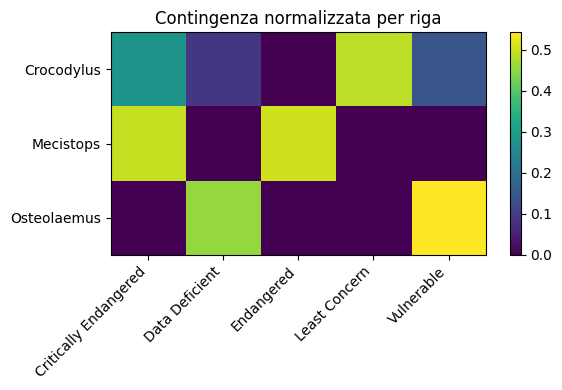

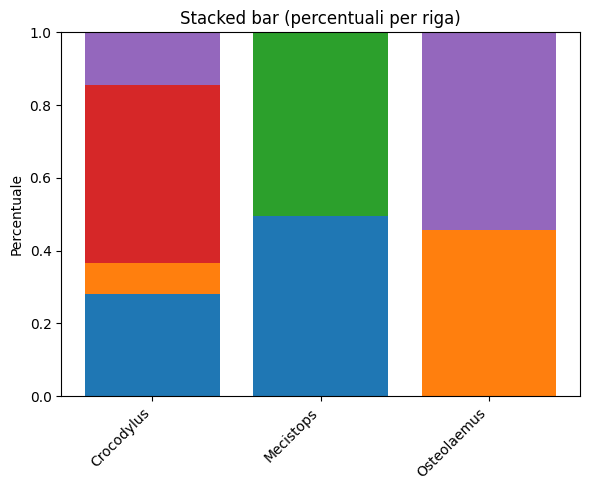

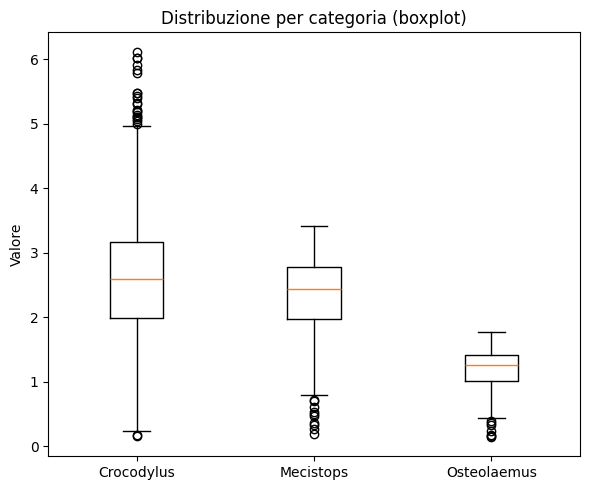

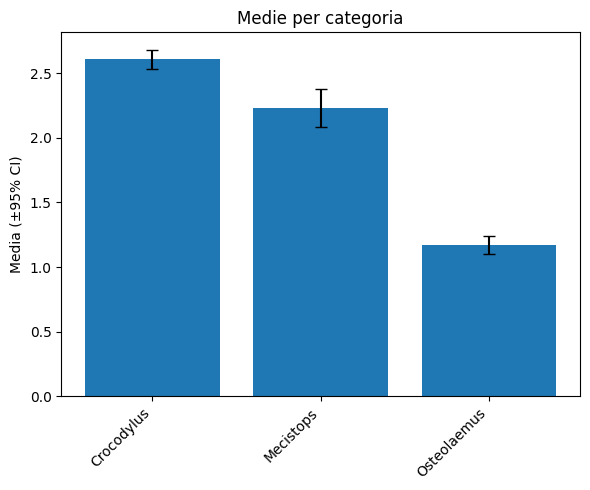

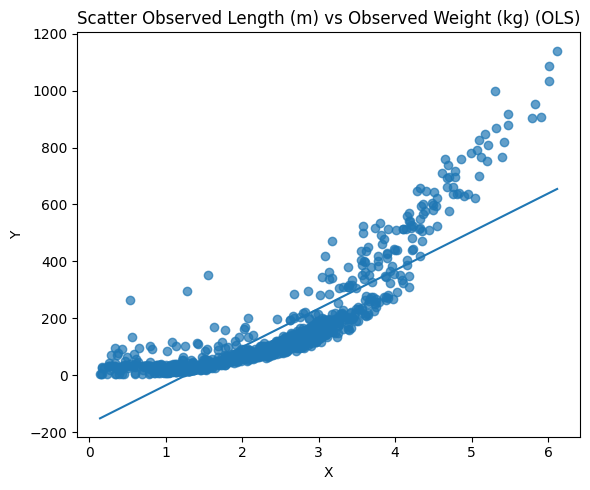

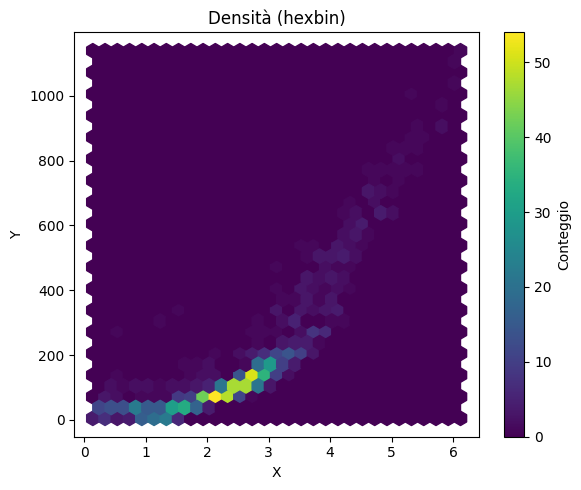

In [44]:
# 1) C×C
res_cc = analyze_bivariate("Genus", "Conservation Status", df, schema, max_cat_x=10, max_cat_y=10)
print(res_cc["pair_type"], res_cc["stats"]["cramers_v"])
for fig in res_cc["figures"]:
    fig.show()

# 2) C×N
res_cn = analyze_bivariate("Genus", "Observed Length (m)", df, schema, max_cat_x=8)
print(res_cn["pair_type"], "eta2:", res_cn["stats"]["eta2"])
for fig in res_cn["figures"]:
    fig.show()

# 3) N×N
res_nn = analyze_bivariate("Observed Length (m)", "Observed Weight (kg)", df, schema)
print(res_nn["pair_type"], "Pearson r:", res_nn["stats"]["pearson_r"])
for fig in res_nn["figures"]:
    fig.show()


In [38]:
from openai import OpenAI

def llm_free(prompt: str,
             model: str = "llama3.1",
             base_url: str = "http://localhost:11434/v1",
             api_key: str = "ollama") -> str:
    client = OpenAI(base_url=base_url, api_key=api_key)
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "Sei un assistente utile e preciso."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=1024,
        seed=1234
    )
    return response.choices[0].message.content

# esempio
print(llm_free("Spiegami in 3 frasi cosa sono i vettori embedding."))


I vettori di embedding rappresentano oggetti complessi come testi, immagini o parole in spazi di dimensione più bassa (ad esempio 2D o 3D), consentendo una rappresentazione visiva e computazionale dei dati.

Questo processo di riduzione della dimensione consente l'analisi e la manipolazione dei dati in modo più efficiente e intuitivo, grazie alla possibilità di visualizzare le relazioni tra gli oggetti rappresentati.

I vettori embedding possono essere utilizzati in applicazioni come la ricerca di testi, la classificazione delle immagini o l'analisi dei sentimenti, consentendo una maggiore comprensione e gestibilità dei dati.
